In [1]:
# load the standard libraries used for data analysis.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

# One random number generator, seeded, so every shuffle-based check below is reproducible. Needed for the current/voltage correlation checks.
RNG = np.random.default_rng(0)

In [2]:
# load in the data files
# index_col=0 drops the unnamed row-index column that was written into each CSV.
#
# Put the three provided CSVs in a folder called "data" next to this notebook.
# The other paths are fallbacks for the machines I developed on.
CANDIDATE_DIRS = [Path("./Data")]
NAME_SETS = [("Sample_Info(in).csv", "OES_Wavelengths(in).csv", "Measurement_Data(in).csv")]

DATA_DIR, NAMES = None, None
for d in CANDIDATE_DIRS:
    for n in NAME_SETS:
        if (d / n[0]).exists():
            DATA_DIR, NAMES = d, n
            break
    if DATA_DIR is not None:
        break
if DATA_DIR is None:
    raise FileNotFoundError("Put the three provided CSVs in a folder called 'data' next to this notebook.")

print("Reading data from:", DATA_DIR.resolve())
samples = pd.read_csv(DATA_DIR / NAMES[0], index_col=0)
waves   = pd.read_csv(DATA_DIR / NAMES[1], index_col=0)
meas    = pd.read_csv(DATA_DIR / NAMES[2], index_col=0)

print("samples:", samples.shape, "| waves:", waves.shape, "| measurements:", meas.shape)

Reading data from: /Users/kavishimam/Documents/SirenOpt_Assesment_KavishImam/Data
samples: (20, 3) | waves: (256, 2) | measurements: (2000, 2306)


In [3]:
# display the samples data
samples.head(3)

,sample_id,thickness,porosity
0,0,92.17,27.36
1,1,70.68,26.89
2,2,83.67,20.26


In [4]:
# display the wavelength data
waves.head(3)

,Bin Number,Wavelength (nm)
0,0,300.00
1,1,303.53
2,2,307.06


In [5]:
# display the measurement data
meas.head(3)

# display all the columns of the df; commented out to keep the output minimal
#meas.info(verbose=True, show_counts=True)

,sample_id,measurement_id,OES_bin_0,OES_bin_1,OES_bin_2,OES_bin_3,OES_bin_4,OES_bin_5,OES_bin_6,OES_bin_7,...,IR_pix_1014,IR_pix_1015,IR_pix_1016,IR_pix_1017,IR_pix_1018,IR_pix_1019,IR_pix_1020,IR_pix_1021,IR_pix_1022,IR_pix_1023
0,0,0,0.115063,0.000000,0.441773,0.00000,1.393143,0.000000,0.504556,1.720359,...,2.234950,2.166049,2.224280,2.264114,2.280424,2.169223,2.250102,2.189151,2.208540,2.251756
1,0,1,1.555201,0.000000,0.000000,0.00000,0.231811,0.311101,0.000000,0.649194,...,2.188157,2.213370,2.123112,2.110970,2.323637,2.202833,2.151540,2.166545,2.191761,2.105117
2,0,2,0.000000,1.690686,0.000000,2.40274,0.542253,0.409082,0.854094,0.000000,...,2.233898,2.252678,2.202053,2.175604,2.195734,2.231898,2.252713,2.250920,2.158203,2.170743


---
### Data inventory

Before any analysis, establish what a row is, how many independent units exist, and whether the columns are what the Assessment Request says they are.

The assessment instructions say the data consists of:
1. Optical emission spectroscopy (OES) intensity measurements
2. Flattened thermal-image measurements
3. Electrical measurements

#### Note: Neither the .csv files nor any portions of the data were directly loaded onto any LLMs as it could be proprietary to the customer.

In [6]:
N_OES, N_T, N_PIX = 256, 512, 1024
OES_COLS = [f"OES_bin_{k}" for k in range(N_OES)]
V_COLS   = [f"V_t_{k}"     for k in range(N_T)]
I_COLS   = [f"I_t_{k}"     for k in range(N_T)]
IR_COLS  = [f"IR_pix_{k}"  for k in range(N_PIX)]

# Raise Exeception if the file does not have the layout the rest of this notebook assumes.
expected = set(OES_COLS) | set(V_COLS) | set(I_COLS) | set(IR_COLS) | {"sample_id", "measurement_id"}
assert expected == set(meas.columns), "Column layout differs from what this notebook assumes."

# Extract to numpy arrays
sid  = meas["sample_id"].to_numpy()
mid  = meas["measurement_id"].to_numpy()
OES  = meas[OES_COLS].to_numpy(dtype=float)
V    = meas[V_COLS].to_numpy(dtype=float)
I    = meas[I_COLS].to_numpy(dtype=float)
IR   = meas[IR_COLS].to_numpy(dtype=float)
WL   = waves["Wavelength (nm)"].to_numpy(dtype=float)
samples = samples.sort_values("sample_id").reset_index(drop=True)
POROSITY  = samples["porosity"].to_numpy(dtype=float)
THICKNESS = samples["thickness"].to_numpy(dtype=float)
SAMPLE_IDS = samples["sample_id"].to_numpy()
N_SAMPLES = len(SAMPLE_IDS)

counts = pd.Series(sid).value_counts()
print(f"rows (measurements)      : {len(meas)}")
print(f"unique samples           : {N_SAMPLES}")
print(f"measurements per sample  : {sorted(counts.unique())}")
print(f"measurement_id range     : {mid.min()}-{mid.max()}")
print(f"missing values anywhere  : {int(meas.isna().to_numpy().sum())}")
print()
print(f"OES bins                 : {N_OES}, {WL.min():.0f}-{WL.max():.0f} nm, "
      f"{np.diff(WL).mean():.2f} nm apart")
print(f"OES value range          : {OES.min():.2f} to {OES.max():.2f}")
print(f"OES values exactly 0.0   : {(OES == 0).mean():.0%}")
print(f"V waveform               : {N_T} samples per row, {V.min():.2f} to {V.max():.2f}")
print(f"I waveform               : {N_T} samples per row, {I.min():.2f} to {I.max():.2f}")
print(f"IR                       : {N_PIX} pixels per row, {IR.min():.2f} to {IR.max():.2f}")

rows (measurements)      : 2000
unique samples           : 20
measurements per sample  : [np.int64(100)]
measurement_id range     : 0-1999
missing values anywhere  : 0

OES bins                 : 256, 300-1200 nm, 3.53 nm apart
OES value range          : 0.00 to 14.01
OES values exactly 0.0   : 51%
V waveform               : 512 samples per row, -7.54 to 7.53
I waveform               : 512 samples per row, -9.55 to 19.96
IR                       : 1024 pixels per row, -0.20 to 4.60


### Data inventory conclusions

The data is made up of 2,000 measurements across 2,307 columns, but only 20 samples, i.e. 100 measurements each.

Each measurement has 256 OES bins (300 to 1200 nm, 3.53 nm per bin), a 512 sample voltage (V) waveform, a 512 sample current (I) waveform, and 1,024 flattened IR image pixels.

Porosity ranges from 20.0 to 32.3 and thickness from 66 to 99. There are no missing values.

The `measurement_id` values run 0 to 1999 across the whole file rather than restarting within each sample, so they look like a global row number rather than an acquisition order. I check this later.

Around half of all OES intensity values are exactly 0.0. That is a lot of zeros for a physical measurement, and it suggests the spectra have been background-subtracted or clipped at a noise floor somewhere before I received them. It is not fatal, but it makes any quantity that divides by a background level unstable, which affects how I build features later.

#### All 100 measurements of a given sample share one porosity value, so they are 100 repeated observations of a single experimental unit, not 100 independent data points.

This is the single most important structural fact in the dataset. It means my effective sample sizefor predicting porosity is 20 and it dictates how any modeling I do will be validated.

---
### Assumptions

The Assessment says to state interpretations where data is ambiguous and proceed. These are mine:

1. Units for porosity and thickness are not given. I did a literature google search on thermal scanning measurements of battery electrodes (Rupnowski et al., *J. Power Sources* 375, 2018) and found that porosity is usually given as a percentage and thickness in $\mu$m. The measurement channels themselves are in arbitrary units. The thermal values run $-0.2$ to $4.6$, which is neither °C nor K. Every analysis below is unaffected by a change of scale, so nothing depends on resolving this, but it would need resolving before a real POC.
2. There are exactly 100 rows per `sample_id`, and `sample_id` joins to a single porosity value. So the rows are repeat measurements on a sample. I treat it as a grouped design throughout.
3. `measurement_id` is a global row identifier, 0 to 1999, not a within-sample acquisition index. I check for drift with acquisition order below and find none.
4. from the data structure, IR pixels form a 32x32 image. 32*32 = 1024 pixels. The assessment brief says "flattened thermal-image", but not the original shape, so I need to verify this from the data.
5. `V_t_*` and `I_t_*` are simultaneous samples of one discharge waveform in arbitrary units, ordered in time.
6. OES intensities are in arbitrary units, already background-subtracted or clipped such that the 0 floor is meaningful.
7. The 20 samples are the population of interest. No information about production lot, operator, measurement date, or spatial location on the electrode is provided, so I cannot check or control for those. This is a real limitation and probably the most important gap in the dataset as they can introduce systematic effects in the model that would be hard to check for.
8. The wavelength binning is 3.53 nm per bin from 300 to 1200 nm.

---
### First starting point

To start I'm going to look for linear relationships via Pearson's correlation coefficient, `r`. Every correlation in this notebook measures how well a straight line describes the relationship between a measurement and porosity. This is the simplest thing to check and the easiest to explain, but it are tradeoff where a strong nonlinear relationship, a threshold effect, or a relationship that only appears when two measurements are combined would all show up as a weak correlation here. A larger dataset would justify looking for non-linear relationships properly.

---
## Is the instrument repeatable enough for any of this to mean anything?

Before looking for relationships, I want to know whether a single measurement actually tells me
something about the electrode, or whether it is mostly scatter. Having 100 repeats of each electrode
makes this checkable, and the answer decides how much weight to put on everything that follows.

In [7]:
# For each channel, split the variation into two parts:
#   - variation BETWEEN electrodes: real differences from one electrode to the next
#   - variation WITHIN one electrode: scatter across its own 100 repeat measurements
#
# The fraction of the total that comes from between-electrode differences tells me
# how much of what I see is the electrode and how much is the instrument.
#
# I also check whether each measurement trends with the order it was recorded in.
# If the instrument warmed up or degraded during the run, later measurements of an
# electrode would differ systematically from earlier ones.
probes = {"optical (total emission)": OES.sum(axis=1),
          "thermal (image mean)":     IR.mean(axis=1),
          "electrical (I rms)":       np.sqrt((I**2).mean(axis=1))}

print(f"{'channel':<26}{'between-electrode sd':>22}{'within-electrode sd':>21}"
      f"{'fraction between':>18}{'trend with order':>18}")
for name, x in probes.items():
    between = np.array([x[sid == s].mean() for s in SAMPLE_IDS]).var(ddof=1)
    within  = np.mean([x[sid == s].var(ddof=1) for s in SAMPLE_IDS])
    drift   = np.mean([np.corrcoef(mid[sid == s], x[sid == s])[0, 1] for s in SAMPLE_IDS])
    print(f"{name:<26}{np.sqrt(between):>22.4f}{np.sqrt(within):>21.4f}"
          f"{between/(between+within):>18.3f}{drift:>+18.3f}")

channel                     between-electrode sd  within-electrode sd  fraction between  trend with order
optical (total emission)                 68.1158               9.6853             0.980            +0.001
thermal (image mean)                      1.2231               0.0016             1.000            +0.011
electrical (I rms)                        0.9325               0.1354             0.979            -0.006


### Conclusion

In all three channels, the standard deviation is the largest in between the electrodes. Thus, almost all of the variation comes from differences between electrodes rather than from scatter within an electrode. For the thermal channel the between-electrode spread is roughly 780 times the within-electrode spread. The trend with recording order is essentially zero everywhere, so nothing drifted during acquisition and assumption 3 holds.

Two consequences:

- Any relationship I find below is a genuine difference between electrodes, not the instrument being noisy.
- Collecting more repeats of these same 20 electrodes doesn't add new information.

---
## Porosity and thickness

Starting with the 20 sample labels, because they bound what any model could possibly achieve.

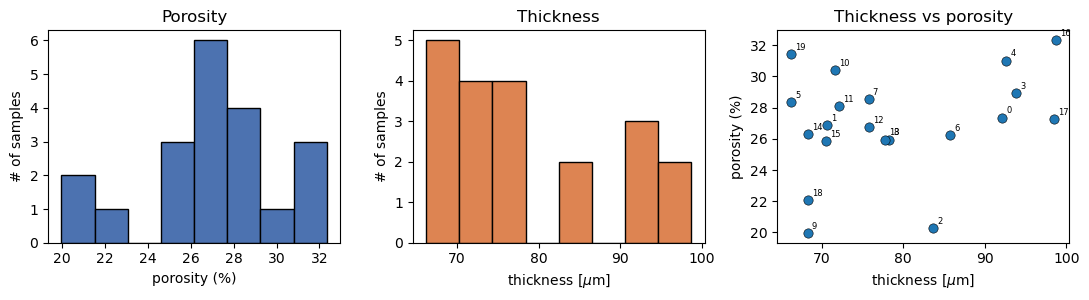

porosity range                     : 20.0 to 32.3 %  (span 12.4)
porosity average                   : 27.00
porosity standard deviation        : 3.32
population standard deviation      : 3.24
thickness range                    : 66 to 99 um
thickness-porosity correlation     : r = +0.284
  95% confidence interval          : -0.18 to +0.65


In [8]:
# make histograms of the porosity and thickness to look at distribution of data
fig, axes = plt.subplots(1, 3, figsize=(11, 3.1))

axes[0].hist(POROSITY, bins=8, color="#4c72b0", edgecolor="black")
axes[0].set_xlabel("porosity (%)")
axes[0].set_ylabel("# of samples")
axes[0].set_title("Porosity")

axes[1].hist(THICKNESS, bins=8, color="#dd8452", edgecolor="black")
axes[1].set_xlabel(r"thickness [$\mu$m]")
axes[1].set_ylabel("# of samples")
axes[1].set_title("Thickness")

def confidence_interval(r, n=None):
    # 95% confidence interval for a correlation, using the Fisher z-transform:
    # convert the correlation to a scale on which it behaves roughly like a normal
    # distribution, build the interval there, then convert back.
    n = N_SAMPLES if n is None else n
    z, se = np.arctanh(r), 1/np.sqrt(n - 3)
    return np.tanh(z - 1.96*se), np.tanh(z + 1.96*se)

# correlation between thickness and porosity, and a scatter to see it directly
r_pt = np.corrcoef(THICKNESS, POROSITY)[0, 1]
axes[2].scatter(THICKNESS, POROSITY, s=45, edgecolor="k", linewidth=0.4)
for k, s in enumerate(SAMPLE_IDS):
    axes[2].annotate(str(s), (THICKNESS[k], POROSITY[k]), fontsize=6, xytext=(3, 3), textcoords="offset points")
axes[2].set_xlabel(r"thickness [$\mu$m]")
axes[2].set_ylabel("porosity (%)")
axes[2].set_title("Thickness vs porosity")

fig.tight_layout()
plt.show()

print(f"porosity range                     : {POROSITY.min():.1f} to {POROSITY.max():.1f} %"
      f"  (span {POROSITY.max()-POROSITY.min():.1f})")
print(f"porosity average                   : {POROSITY.mean():.2f}")
print(f"porosity standard deviation        : {POROSITY.std(ddof=1):.2f}")
print(f"population standard deviation      : {POROSITY.std(ddof=0):.2f}")
print(f"thickness range                    : {THICKNESS.min():.0f} to {THICKNESS.max():.0f} um")
lo_pt, hi_pt = confidence_interval(r_pt)
print(f"thickness-porosity correlation     : r = {r_pt:+.3f}")
print(f"  95% confidence interval          : {lo_pt:+.2f} to {hi_pt:+.2f}")

### Conclusions from porosity and thickness

The porosity spread is 12.4 % points, clustered in the mid-20s. So any predictive modeling can only be trusted over this range and the population std above is the target for an predictive modeling.

The correlation calculated from 20 samples is an estimate, and different 20 electrodes from the same process would have given a different number. 

The 95% confidence interval is the range of values consistent with what was measured. If this study were repeated many times, each on a different set of n electrodes from the same process, intervals built this way would contain the true correlation 95% of the time. If the interval excludes zero, a relationship is established; if it includes zero, the data cannot rule out there being no relationship at all. The width matters as much as the position, because it says how precisely the number has been measured. Note that it is NOT "a 95% probability the true correlation is in this range". The true value is fixed. It is the interval that varies from study to study. I think a stronger statement like that needs a Bayesian interval calculation but that requires assumptions about the answer before seeing the data, called a prior.

I made the Conf. Int. using the Fisher z-transform, which is the standard method for correlations. It assumes the two quantities follow a joint normal distribution (at 20 samples I can't confirm or deny it but proceed with this assumption). The main alternative would be a bootstrap, repeatedly resampling electrodes with replacement, but with only 20 points each resample would contain duplicates and drop roughly a third of the data, and bootstrap intervals for correlations can behave poorly at this size. The analytic interval is the more defensible choice here.

Thickness and porosity are only weakly related, and the confidence interval for that correlation includes zero, so it seems they are not related at all from 20 samples. That makes sense in physics terms because how can thickness tell me how porous a sample is. That's the whole point of doing plasma measurements.

---
## Signal-by-signal exploration

Look at each measurement by itself.

### Firstly, the OES spectra

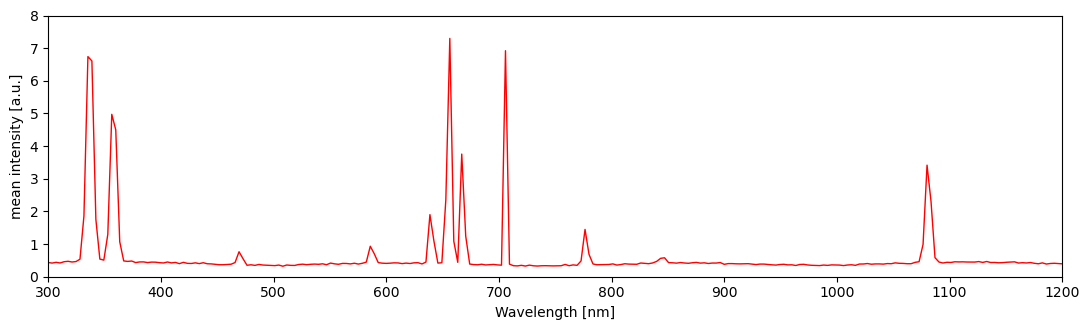

Signal intensity is highest for bins:
  bin  10   335.29 nm  mean =   6.74
  bin  11   338.82 nm  mean =   6.61
  bin  16   356.47 nm  mean =   4.97
  bin  17   360.00 nm  mean =   4.50
  bin 101   656.47 nm  mean =   7.30
  bin 104   667.06 nm  mean =   3.76
  bin 115   705.88 nm  mean =   6.92
  bin 221  1080.00 nm  mean =   3.42

median bin intensity for comparison: 0.41


In [9]:
# make an OES spectrum
# looking at the mean of all the spectra as looking at them individually would be too cumbersome.
mean_spec = OES.mean(axis=0)

def bin_at(nm):
    # Index of the bin whose centre is closest to wavelength.
    return int(np.argmin(np.abs(WL - nm)))

fig, ax = plt.subplots(1, 1, figsize=(11, 3.4))
ax.plot(WL, mean_spec, lw=1.0, color="red")
ax.set_ylim(0.0, 8.0)
ax.set_xlim(300.0, 1200.0)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("mean intensity [a.u.]")
fig.tight_layout()
plt.show()

top = np.argsort(mean_spec)[::-1][:8]
print("Signal intensity is highest for bins:")
for b in sorted(top):
    print(f"  bin {b:3d}  {WL[b]:7.2f} nm  mean = {mean_spec[b]:6.2f}")
print(f"\nmedian bin intensity for comparison: {np.median(mean_spec):.2f}")

### Conclusion

The spectrum could be from the cold plasma discharge interacting with the material. I'm not sure what the peaks mean with regards to wavelength emissions. I would need to check with Cristina or one of the experimental scientists at SirenOpt to be sure, as I don't know what kind of plasma or material (with elemental composition) was being measured.

The eight brightest bins are prominent on a flat background. They sit far above the median bin intensity printed above, so there is a clear separation between peaks and background rather than a gradual roll-off.

I'm now going to see if porosity can be correlated with the peaks. Because I can't identify the peaks chemically, I select them purely by brightness.

**Note** bins 10 and 11 and bins 16 and 17 are showing as distinct wavelength excitations with the 3.53 nm/bins. Are they not resolved due to instrument limitations? Need to check with Christina or a SirenOpt scientist.

---
### Approach

A correlation coefficient answers if there is a linear relationship between the measured data and porosity.

- If nothing correlates with porosity, then modeling won't work either, because a model can only exploit relationships that are already in the data. Correlations take seconds to compute, so this is the cheapest possible test of whether the project has any chance.

- There are 2,304 measurement columns and 20 samples. It would be challenging to model with all of them since there are far more unknown than data points.

- It's also easy to explain to a process engineer/experimental material scientist if a certain measured data tracks with porosity. 

**Tradeoffs:**

- It only finds linear relationships, as noted in the previous assumptions.
- Correlation doesn't imply causation. Both variables could be driven by something that was not measured.
- Variables can correlated purely by chance.

### Does anything in the spectrum track with porosity?

I'm now going to check each spectral bin against porosity at the sample level (n=20), then ask whether any correlation is concentrated in the bright peaks.

**Variable hypothesis:** are porosity and the spectrum peaks correlated?

**Control hypothesis:** if only the peaks matter, then the flat background part of the spectrum should show no correlation. If the background does correlate, that would suggest something is scaling the whole spectrum, which would point to a systematic effect.

**Disclaimer:** there could be real physics spread across the entire spectrum rather than in specific peaks. I would need to look more deeply into the literature or consult an expert to know how to interpret a plasma emission spectrum properly.

Two reference lines are drawn on the plot below. The first is the size a correlation must exceed before it would be considered unlikely to have arisen by chance, given only 20 samples. The second is a stricter version of the same thing, adjusted for the fact that I am looking at 256 bins at once and so have 256 chances to find something that looks good by accident.

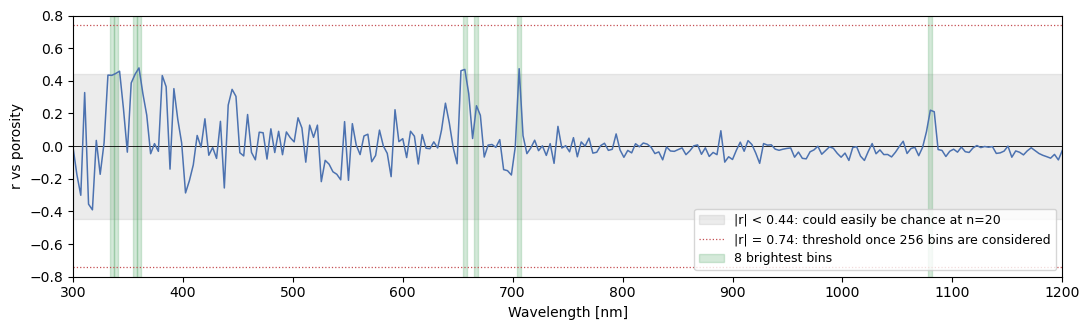

quantity                        r vs porosity   95% confidence interval   width
summed peak emission                   +0.522            +0.10 to +0.78    0.68
summed background emission             +0.008            -0.44 to +0.45    0.89
total emission                         +0.112            -0.35 to +0.53    0.88

mean r across the   8 peak bins       : +0.401
mean r across the 248 background bins : +0.001

number of bins kept   r(peaks)   r(background)
              4        +0.458         +0.044
              6        +0.459         +0.021
              8        +0.522         +0.008
             12        +0.538         -0.010
             16        +0.535         -0.019
             20        +0.530         -0.025


In [10]:
def sample_mean(X):
    # Average the 100 repeat measurements within each sample -> (20, n_features).
    X = X if X.ndim == 2 else X.reshape(-1, 1)
    return np.stack([X[sid == s].mean(axis=0) for s in SAMPLE_IDS])

def corr_with(X2d, y):
    # Straight-line correlation of every column of X2d against y.
    Xc = X2d - X2d.mean(axis=0)
    yc = y - y.mean()
    denom = np.sqrt((Xc**2).sum(axis=0) * (yc**2).sum()) + 1e-12
    return (Xc * yc[:, None]).sum(axis=0) / denom

OES_S = sample_mean(OES)                     # (20, 256): one averaged spectrum per sample
r_bin = corr_with(OES_S, POROSITY)

# ---------------------------------------------------------------------------
# Split the spectrum empirically: the N brightest bins ("peaks") vs the rest
# ("background"). Bins are chosen by INTENSITY only
# so this selection cannot inflate the correlations below.
# ---------------------------------------------------------------------------
N_PEAKS = 8
peak_bins = np.sort(np.argsort(mean_spec)[::-1][:N_PEAKS])

PEAK_MASK = np.zeros(N_OES, dtype=bool)
PEAK_MASK[peak_bins] = True
BKG_MASK = ~PEAK_MASK

# How big does a correlation have to be before it is unlikely to be chance?
# r_single: for one test.  r_many: adjusted for having looked at all 256 bins.
def r_threshold(alpha, n):
    t = stats.t.ppf(1 - alpha/2, n - 2)
    return t / np.sqrt(t**2 + n - 2)
r_single, r_many = r_threshold(0.05, N_SAMPLES), r_threshold(0.05/N_OES, N_SAMPLES)

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.axhline(0, color="k", lw=0.6)
ax.axhspan(-r_single, r_single, color="grey", alpha=0.15,
           label=f"|r| < {r_single:.2f}: could easily be chance at n=20")
ax.axhline(r_many, color="#c44e52", ls=":", lw=0.9,
           label=f"|r| = {r_many:.2f}: threshold once 256 bins are considered")
ax.axhline(-r_many, color="#c44e52", ls=":", lw=0.9)
for b in peak_bins:                                   # shade the brightest bins
    ax.axvspan(WL[b] - 1.8, WL[b] + 1.8, color="#55a868", alpha=0.25, label="_" if b != peak_bins[0] else f"{N_PEAKS} brightest bins")

ax.plot(WL, r_bin, lw=1.1, color="#4c72b0")
ax.set_ylim(-0.8, 0.8)
ax.set_xlim(300.0, 1200.0)
ax.set_xlabel("Wavelength [nm]")
ax.set_ylabel("r vs porosity")
ax.legend(fontsize=9, loc="lower right")
fig.tight_layout()
plt.show()

peak_sum, bkg_sum = OES_S[:, PEAK_MASK].sum(axis=1), OES_S[:, BKG_MASK].sum(axis=1)
r_peak = np.corrcoef(peak_sum, POROSITY)[0, 1]
r_bkg  = np.corrcoef(bkg_sum, POROSITY)[0, 1]
r_tot  = np.corrcoef(OES_S.sum(axis=1), POROSITY)[0, 1]

print(f"{'quantity':<30}{'r vs porosity':>15}{'95% confidence interval':>26}{'width':>8}")
for label, r_ in [("summed peak emission", r_peak), ("summed background emission", r_bkg), ("total emission", r_tot)]:
    lo, hi = confidence_interval(r_)
    print(f"{label:<30}{r_:>+15.3f}{f'{lo:+.2f} to {hi:+.2f}':>26}{hi-lo:>8.2f}")
print(f"\nmean r across the {PEAK_MASK.sum():3d} peak bins       : {r_bin[PEAK_MASK].mean():+.3f}")
print(f"mean r across the {BKG_MASK.sum():3d} background bins : {r_bin[BKG_MASK].mean():+.3f}")

# Does the result depend on picking exactly 8 bins? Sweep the cut-off.
print("\nnumber of bins kept   r(peaks)   r(background)")
for n in [4, 6, 8, 12, 16, 20]:
    m = np.zeros(N_OES, dtype=bool)
    m[np.argsort(mean_spec)[::-1][:n]] = True
    print(f"{n:>15}      {np.corrcoef(OES_S[:, m].sum(axis=1), POROSITY)[0,1]:>+8.3f}"
          f"       {np.corrcoef(OES_S[:, ~m].sum(axis=1), POROSITY)[0,1]:>+8.3f}")

### Conclusion

The confidence intervals in the table above are explained in the porosity and thickness section. In short, an interval excluding zero means a relationship can be established, and the width of the interval says how precisely it has been measured. Every interval here is wide, which is the honest expression of how little 20 samples pin anything down.

Most of the correlation with porosity is concentrated in the 8 bright peaks, near 335 to 360, 656, 667, 706 and 1080 nm. Summed peak intensity rises with porosity at `r = +0.52`, with a 95% confidence interval of `+0.10` to `+0.78`. That excludes zero, so a relationship is there, but the interval is very wide so the data is equally consistent with a weak effect and a strong one.

The background correlation is +0.008 with confidence interval is `-0.44` to `+0.45`, so no relationship with porosity can be established and it serves as a good control check. A systematic effect large enough to explain a peak correlation of +0.52, would bias the whole spectrum including the background and would very likely have been visible. It isn't, which makes an instrument explanation for the peak correlation unlikely.

Note also that total emission (r = +0.11) is a worse than peak emission, because the uninformative background dominates the sum and dilutes the signal peaks. This is why I should build features from the peak bins specifically, rather than training a predictive model with all 256 bins or a single total.

The correlation strengthens a little as more peaks are included, which suggests there may be additional weaker peaks that also respond, worth revisiting with more samples. And at n = 20, having looked at 256 bins, nothing clears the stricter threshold on the plot.

---
### Thermal image correlation with porosity

The images arrived as flat lists of 1,024 numbers with no stated shape, so before anything else I need to work out how to reconstruct the image.

In [11]:
# Recover the image geometry from the data itself.
#
# When an image is flattened row by row, element k ends up at row k//W and
# column k%W for some width W. That means:
#   - elements 1 apart were side by side in the image,
#   - elements W apart were directly above and below each other.
# If I guess W wrong, the "above and below" pairs are not really neighbours.
#
# A thermal field is smooth, so genuinely neighbouring pixels have almost the
# same value. The correct width should therefore make both correlations high.
#
# Note: elements 1 apart are next to each other in the flat list
# whatever Ws I guess, so the side-by-side correlation stays high for nearly every
# candidate and tells me little. The above-and-below correlation is what actually
# identifies the width.

def neighbour_corr(img):
    h = np.corrcoef(img[:, :-1].ravel(), img[:, 1:].ravel())[0, 1]   # side by side
    v = np.corrcoef(img[:-1, :].ravel(), img[1:, :].ravel())[0, 1]   # above and below
    return h, v

probe = IR[0]
widths = [w for w in [2, 4, 8, 16, 32, 64, 128, 256, 512] if N_PIX % w == 0]

print(f"{'width':>8}{'height':>9}{'side-by-side r':>17}{'above-below r':>16}")
for w in widths:
    h, v = neighbour_corr(probe.reshape(N_PIX // w, w))
    print(f"{w:>8}{N_PIX//w:>9}{h:>+17.3f}{v:>+16.3f}")

h, v = neighbour_corr(RNG.permutation(probe).reshape(32, 32))
print(f"{'shuffled':>8}{'':>9}{h:>+17.3f}{v:>+16.3f}")

# Check the answer is not a quirk of this one measurement.
stab = np.array([neighbour_corr(IR[i].reshape(32, 32)) for i in range(0, len(IR), 200)])
print(f"\n32x32 across 10 different measurements: side-by-side {stab[:,0].mean():.3f} "
      f"+/- {stab[:,0].std():.3f}, above-below {stab[:,1].mean():.3f} +/- {stab[:,1].std():.3f}")

   width   height   side-by-side r   above-below r
       2      512           +0.994          +0.808
       4      256           +0.994          +0.602
       8      128           +0.994          +0.189
      16       64           +0.994          -0.243
      32       32           +0.994          +0.992
      64       16           +0.945          +0.983
     128        8           +0.924          +0.950
     256        4           +0.913          +0.846
     512        2           +0.908          +0.683
shuffled                    +0.028          -0.013

32x32 across 10 different measurements: side-by-side 0.968 +/- 0.038, above-below 0.967 +/- 0.038


The shuffled row is a control and scrambling the same 1,024 values destroys the picture, and both correlations collapse to zero, which confirms the test is responding to real spatial structure rather than being high for any arrangement of these numbers.

A width of 32 is the smallest width at which the above-and-below correlation reaches its maximum, and it is the only width where both correlations are maximal at once. Widths of 64 and 128 keep a high above-and-below correlation only because they are multiples of 32, so they step over whole rows of the real image and land on smooth territory anyway; their side-by-side correlation drops instead, because their "rows" wrap across real row boundaries. A width of 16 goes negative, since half a row lands on the opposite side of a picture that is brightest in the middle.

So it is ok to proceed with the 32 x 32 image reconstruction.

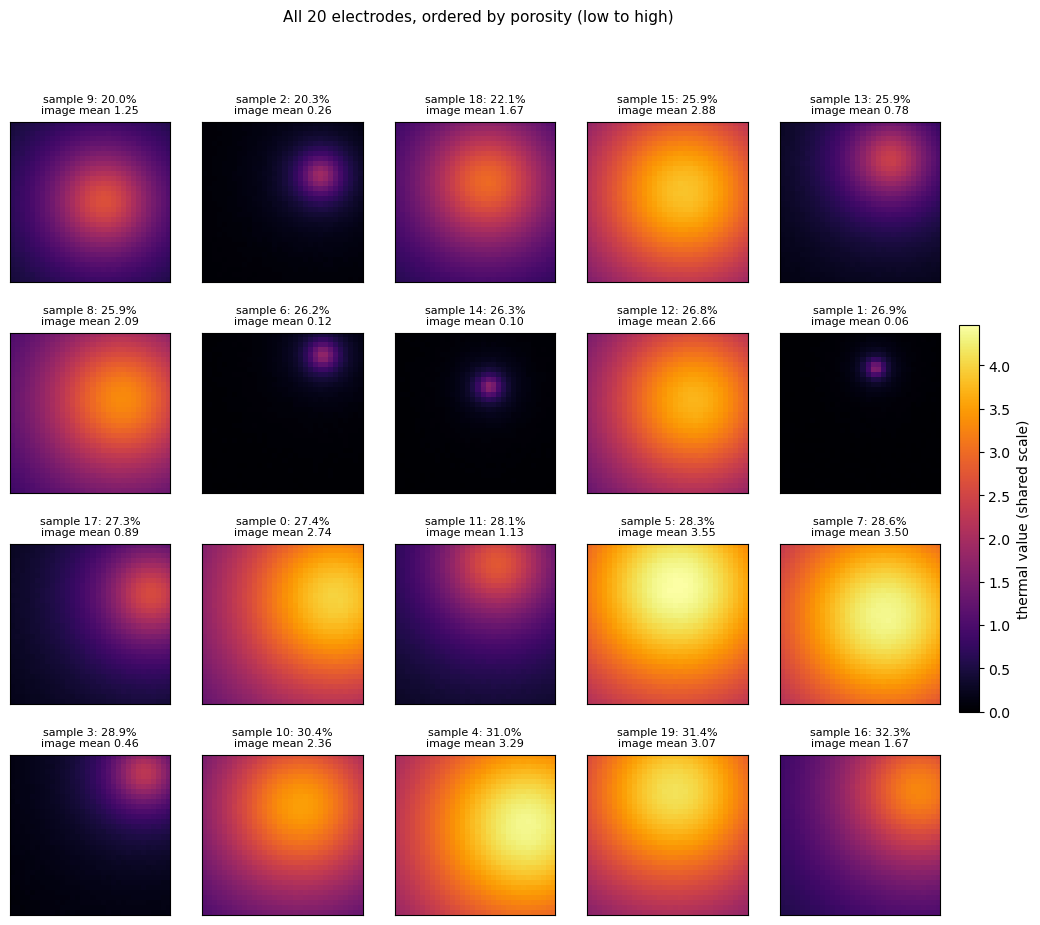

In [12]:
#plotting the 32 x 32 thermal image for all 20 samples
IR_S = sample_mean(IR)
img_mean = IR_S.mean(axis=1)
r_pix = corr_with(IR_S, POROSITY).reshape(32, 32)
order = np.argsort(POROSITY)                 # low porosity -> high porosity

fig, axes = plt.subplots(4, 5, figsize=(12.5, 10.5))
vmin, vmax = IR_S.min(), IR_S.max()          # one shared scale, so brightness is comparable
for ax, k in zip(axes.ravel(), order):
    h = ax.imshow(IR_S[k].reshape(32, 32), cmap="inferno", vmin=vmin, vmax=vmax)
    ax.set_title(f"sample {SAMPLE_IDS[k]}: {POROSITY[k]:.1f}%\nimage mean {img_mean[k]:.2f}",
                 fontsize=8)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
fig.colorbar(h, ax=axes, fraction=0.02, pad=0.02, label="thermal value (shared scale)")
fig.suptitle("All 20 electrodes, ordered by porosity (low to high)", y=0.98, fontsize=11)
plt.show()

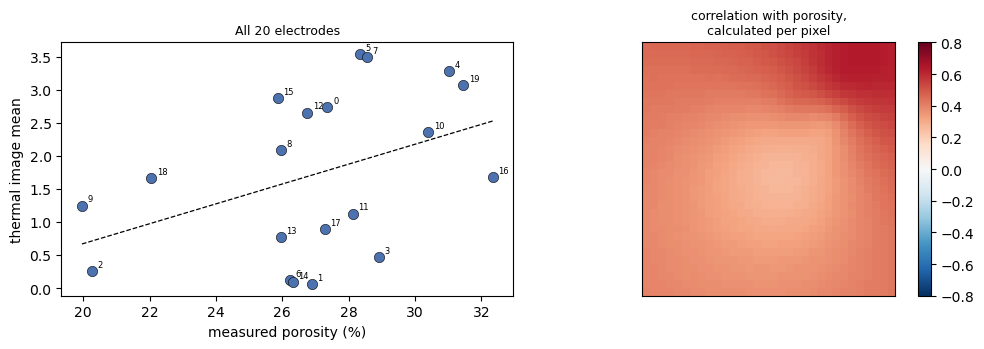

whole-image mean vs porosity           : r = +0.408
95% confidence interval                : -0.04 to +0.72
recomputed dropping each electrode     : +0.325 to +0.459
size a correlation must reach at n=20  : 0.444

image mean across all 20 electrodes    : 0.06 to 3.55
image mean among the 5 electrodes near 26% : 0.10 to 2.88

per-pixel correlations that are positive: 100%
spread of those per-pixel correlations  : sd 0.084

largest single-pixel correlation        : 0.637
same quantity on shuffled labels        : median 0.270, 95th percentile 0.515
how often shuffling beat the real value : 0.010


In [13]:
# The thermal porosity correlation scatter plot, correlation with the net porosity and numerical calculations.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].scatter(POROSITY, img_mean, s=55, color="#4c72b0", edgecolor="k", linewidth=0.4)
for k in range(N_SAMPLES):
    axes[0].annotate(str(SAMPLE_IDS[k]), (POROSITY[k], img_mean[k]), fontsize=6, xytext=(4, 3), textcoords="offset points")
b_, a_ = np.polyfit(POROSITY, img_mean, 1)
xx = np.linspace(POROSITY.min(), POROSITY.max(), 10)
axes[0].plot(xx, a_ + b_ * xx, "k--", lw=0.9)
axes[0].set_xlabel("measured porosity (%)")
axes[0].set_ylabel("thermal image mean")
axes[0].set_title("All 20 electrodes", fontsize=9)

h = axes[1].imshow(r_pix, cmap="RdBu_r", vmin=-0.8, vmax=0.8)
axes[1].set_title("correlation with porosity,\ncalculated per pixel", fontsize=9)
axes[1].set_xticks([])
axes[1].set_yticks([])
axes[1].grid(False)
fig.colorbar(h, ax=axes[1], fraction=0.046)
fig.tight_layout()
plt.show()

r_ir = np.corrcoef(img_mean, POROSITY)[0, 1]
lo_ir, hi_ir = confidence_interval(r_ir)
# Drop one electrode at a time and recompute, to see whether any single electrode
# is carrying the relationship on its own. This asks a different question from the
# confidence interval: the interval asks how much the number would move with a
# different 20 electrodes, this asks whether one electrode in this set is doing
# the work.
drop_one = [np.corrcoef(np.delete(img_mean, k), np.delete(POROSITY, k))[0, 1]
            for k in range(N_SAMPLES)]
near26 = np.abs(POROSITY - 26) < 0.4

print(f"whole-image mean vs porosity           : r = {r_ir:+.3f}")
print(f"95% confidence interval                : {lo_ir:+.2f} to {hi_ir:+.2f}")
print(f"recomputed dropping each electrode     : {min(drop_one):+.3f} to {max(drop_one):+.3f}")
print(f"size a correlation must reach at n=20  : {r_single:.3f}")
print()
print(f"image mean across all 20 electrodes    : {img_mean.min():.2f} to {img_mean.max():.2f}")
print(f"image mean among the {near26.sum()} electrodes near 26% : "
      f"{img_mean[near26].min():.2f} to {img_mean[near26].max():.2f}")
print()
print(f"per-pixel correlations that are positive: {(r_pix > 0).mean():.0%}")
print(f"spread of those per-pixel correlations  : sd {r_pix.std():.3f}")

# The single best pixel is the largest of 1,024 correlations.
# With that many pixels, one can look good by chance. 
# But this would require 1024 tests to check because neighbouring pixels
# carry almost the same information.
# Instead I can shuffle the porosity labels, recompute the same largest pixel out of 1,024
# and see how large it gets by chance under the real pixel structure.
obs_max = np.abs(r_pix).max()
shuffled_max = np.array([np.abs(corr_with(IR_S, RNG.permutation(POROSITY))).max()
                         for _ in range(1000)])
print(f"\nlargest single-pixel correlation        : {obs_max:.3f}")
print(f"same quantity on shuffled labels        : median {np.median(shuffled_max):.3f}, "
      f"95th percentile {np.percentile(shuffled_max, 95):.3f}")
print(f"how often shuffling beat the real value : "
      f"{(1 + (shuffled_max >= obs_max).sum())/1001:.3f}")

### Conclusion

The shape of the thermal image is the same for every electrode. The overall brightness between the electrodes changes but the circular pattern stays the same. The per-pixel map also shows positive everywhere with very little variation, so porosity shifts the whole image up or down rather than changing one region. I think we can keep the mean thermal image to study the correlations rather than individual pixels. The shuffled porosity label check also shows that the correlation with porosity is not likely at the pixel level.

The porosity and thermal image mean correlation is weak. The trend line shows a positive slope at `r = +0.41`, but its 95% confidence interval runs from `-0.04` to `+0.72`. Since the conf. int. includes zero, this dataset cannot establish that a relationship exists here at all. The scatter is large: image mean ranges from `0.06` to `3.55` across the 20 electrodes, and from `0.10` to `2.88` among the five electrodes sitting at essentially the same porosity near 26%.

The drop-one-electrode check shows that depending on which single electrode is removed, the correlation lands anywhere from `+0.33` to `+0.46`, which straddles the `0.44` threshold printed above. In other words, whether this relationship looks statistically convincing depends on which electrodes happen to be in the dataset but there is not one outlier electrode sample producing the effect.

Something else is clearly driving most of the variation in thermal level though, and identifying what would be a good question for the customer's process team.

---
### Electrical measurements and porosity

I'm not sure about the voltage or current response of the material as a function of porisity, I'll plot it and see. 

Everything below is a plain summary of the raw waveforms in the time domain: a ratio, an average, or a count.

In [14]:
v_rms = np.sqrt((V**2).mean(axis=1))            # root mean square of the voltage
i_rms = np.sqrt((I**2).mean(axis=1))            # root mean square of the current
P_mean = (V * I).mean(axis=1)                   # power
power_factor = P_mean / (v_rms * i_rms)         # power factor
i_crest = np.abs(I).max(axis=1) / i_rms         # peak height divided by root mean square of peak
i_zc = np.array([np.sum(np.diff(np.sign(x - x.mean())) != 0) for x in I], dtype=float) # zero crossings of current waveform

elec = {"V_rms": v_rms, "I_rms": i_rms, "P_mean": P_mean, "power_factor": power_factor, "I_crest": i_crest, "I_zero_crossings": i_zc}

# The last column removes the influence of thickness, to check whether a quantity
# is really responding to porosity or just tracking electrode geometry.
r_pt = np.corrcoef(POROSITY, THICKNESS)[0, 1]
print(f"{'quantity':<22}{'r vs porosity':>15}{'r vs thickness':>16}"
      f"{'r vs porosity, thickness removed':>34}")
for name, x in elec.items():
    xs = sample_mean(x).ravel()
    rp, rt = np.corrcoef(xs, POROSITY)[0, 1], np.corrcoef(xs, THICKNESS)[0, 1]
    print(f"{name:<22}{rp:>+15.3f}{rt:>+16.3f}"
          f"{(rp - rt*r_pt)/np.sqrt((1-rt**2)*(1-r_pt**2)):>+34.3f}")

# Each waveform is divided by its own size first, so only shape is compared.
V_S = np.stack([(V[sid == s]/v_rms[sid == s, None]).mean(axis=0) for s in SAMPLE_IDS])
I_S = np.stack([(I[sid == s]/i_rms[sid == s, None]).mean(axis=0) for s in SAMPLE_IDS])
print(f"\nsmallest correlation between any two electrodes' voltage shapes : "
      f"{np.corrcoef(V_S).min():.4f}")
print(f"largest disagreement between voltage shapes at any time point   : "
      f"{(V_S.max(0)-V_S.min(0)).max():.4f}")
print(f"smallest correlation between any two electrodes' current shapes : "
      f"{np.corrcoef(I_S).min():.4f}")

quantity                r vs porosity  r vs thickness  r vs porosity, thickness removed
V_rms                          +0.362          +0.134                            +0.341
I_rms                          -0.000          +0.057                            -0.017
P_mean                         +0.306          +0.138                            +0.281
power_factor                   +0.384          +0.117                            +0.368
I_crest                        -0.575          +0.000                            -0.600
I_zero_crossings               -0.470          -0.064                            -0.472

smallest correlation between any two electrodes' voltage shapes : 1.0000
largest disagreement between voltage shapes at any time point   : 0.0176
smallest correlation between any two electrodes' current shapes : 0.6146


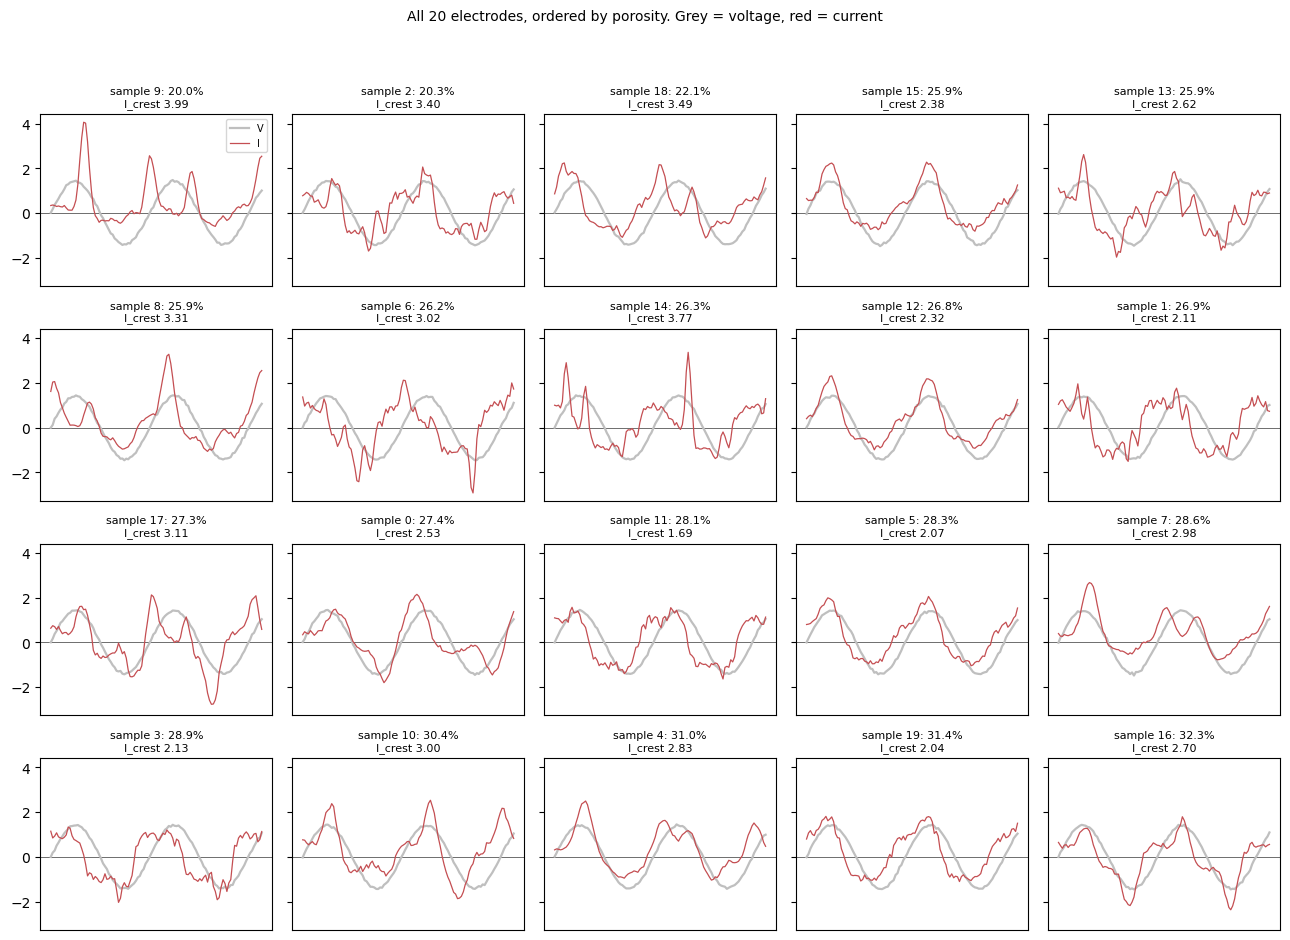

In [15]:
crest_s = sample_mean(i_crest).ravel()
# With 100 repeats per electrode I can say how precisely each electrode's crest factor is by 
# taking its across 100 measurements dividing by sqrt of 100 measurements 
crest_err = np.array([i_crest[sid == s].std(ddof=1)/np.sqrt((sid == s).sum()) for s in SAMPLE_IDS])
order = np.argsort(POROSITY)

def representative(k):
    # The measurement closest to that electrode's middle crest factor, so each panel shows a typical record.
    rows = np.where(sid == SAMPLE_IDS[k])[0]
    return rows[np.argmin(np.abs(i_crest[rows] - np.median(i_crest[rows])))]
n_show = 110

fig, axes = plt.subplots(4, 5, figsize=(13, 9.5), sharey=True)
for ax, k in zip(axes.ravel(), order):
    r_ = representative(k)
    ax.axhline(0, color="k", lw=0.4)
    ax.plot(np.arange(n_show), (V[r_]/v_rms[r_])[:n_show], lw=1.6, color="0.75", label="V")
    ax.plot(np.arange(n_show), (I[r_]/i_rms[r_])[:n_show], lw=0.9, color="#c44e52", label="I")
    ax.set_title(f"sample {SAMPLE_IDS[k]}: {POROSITY[k]:.1f}%\nI_crest {crest_s[k]:.2f}", fontsize=8)
    ax.set_xticks([])
axes[0, 0].legend(fontsize=7, loc="upper right")
fig.suptitle("All 20 electrodes, ordered by porosity. Grey = voltage, red = current", y=0.985, fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Observation:** the voltage (gray) seems to be identical across all electrodes while the current (red) response changes across the electrodes. I guess I would need to correlate porosity with that magnitude and shape of the current waveform.

I'm going to use waveform features like amplitude, root mean square value, crest value (indicates how extreme the peaks are in a waveform) and zero crossings to see if they correlate with porosity.

The crest parameter shows the largest correlation with porosity as compared to other parameters.

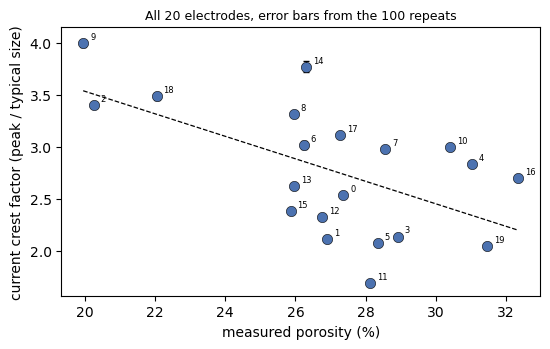

crest factor vs porosity               : r = -0.575
95% confidence interval                : -0.81 to -0.18
recomputed dropping each electrode     : -0.616 to -0.450
crest factor vs thickness              : r = +0.000

uncertainty on one electrode's value   : +/- 0.020
spread of values between electrodes    : 0.626


In [16]:
# scatter plot of current crest factor and porosity.
fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.errorbar(POROSITY, crest_s, yerr=crest_err, fmt="none", ecolor="k", elinewidth=0.8, capsize=2)
ax.scatter(POROSITY, crest_s, s=55, color="#4c72b0", edgecolor="k", linewidth=0.4, zorder=3)
for k in range(N_SAMPLES):
    ax.annotate(str(SAMPLE_IDS[k]), (POROSITY[k], crest_s[k]), fontsize=6, xytext=(5, 3), textcoords="offset points")
b_, a_ = np.polyfit(POROSITY, crest_s, 1)
xx = np.linspace(POROSITY.min(), POROSITY.max(), 10)
ax.plot(xx, a_ + b_*xx, "k--", lw=0.9)
ax.set_xlabel("measured porosity (%)")
ax.set_ylabel("current crest factor (peak / typical size)")
ax.set_title("All 20 electrodes, error bars from the 100 repeats", fontsize=9)
fig.tight_layout()
plt.show()

r_cr = np.corrcoef(crest_s, POROSITY)[0, 1]
lo_cr, hi_cr = confidence_interval(r_cr)
drop_one = [np.corrcoef(np.delete(crest_s, k), np.delete(POROSITY, k))[0, 1] for k in range(N_SAMPLES)]

print(f"crest factor vs porosity               : r = {r_cr:+.3f}")
print(f"95% confidence interval                : {lo_cr:+.2f} to {hi_cr:+.2f}")
print(f"recomputed dropping each electrode     : {min(drop_one):+.3f} to {max(drop_one):+.3f}")
print(f"crest factor vs thickness              : r = {np.corrcoef(crest_s, THICKNESS)[0,1]:+.3f}")
print()
print(f"uncertainty on one electrode's value   : +/- {crest_err.mean():.3f}")
print(f"spread of values between electrodes    : {crest_s.std(ddof=1):.3f}")

### Conclusion

For all 20 electrodes, the voltage shapes have a smallest pairwise correlation of `1.0000` and don't deviate by more than `0.018`, so they are interchangeable. The current shapes drop as low as `0.61` correlation with each other, so they differ by electrode. Any porosity information in these electrical measurements must be in the current data.

`i_rms`, which is the rms magnitude of the current, correlates with porosity at `r = 0.000`. The crest factor, which is the peak height divided by the rms and so describes how extreme the peaks are in a waveform, reaches r = $-0.575$. More porous electrodes give a smoother, less spiky current. This is the strongest single relationship anywhere in the dataset.

Its 95% confidence interval is `-0.81` to `-0.18`. That excludes zero, so unlike the thermal channel a relationship is established here. But the width is the point worth carrying forward: the data is consistent with an effect strong enough to build a measurement on, and equally consistent with one barely worth pursuing. This means that 20 electrodes are likely not enough to tell if a strong relationship can be established with porosity and if a predictive model can be made.

`I_crest` also has zero correlation with thickness, and the thickness removed column in the table above is unchanged at `-0.60`, so sample thickness can be neglected. Dropping any single electrode leaves the correlation between `-0.45` and `-0.62`, all of which clear the 0.44 threshold. Thus, unlike the thermal image measurements, `I_crest` correlations with porosity one does not depend on which electrodes happen to be included.

Because each electrode was measured 100 times, its crest factor is pinned down to about $\pm 0.02$, against a spread of `0.63` between electrodes. The error bars are smaller than the plot markers. That means the scatter around the trend line is not measurement uncertainty  and a systematic effect besides porosity is likely contributing to the scatter. Identifying what would be a good question for the process engineering team.

---
### Conclusions from Three Independent Measurement Data

| Channel | Strongest link | 95% confidence interval | Direction, and what it suggests |
|---|---|---|---|
| OES | peak emission, r=+0.52 | [0.10, 0.78] | More porous sample gives brighter emission at specific wavelengths |
| Thermal | mean of 20 images, r=+0.41 | [−0.04, 0.72] | More porous sample gives higher thermal response but Conf. Int. includes zero, so no relationship established. Weakest of the three |
| Electrical | $I_{crest}$ factor, r=−0.58 | [−0.81, −0.18] | More porous sample gives less "spiky" current response. The current's overall size does not change at all (r = 0.00), only its shape |

Every conf. ints. are roughly 0.6 to 0.8 wide. Two of the three exclude zero, so those relationships are established. But a porosity predictive model will likely not perform well. Nevertheless, since the customer asks to estimate porosity so I'll proceed to answer this question.

One things that still makes me cautious is how to relate these correlations to the physics of the electrodes. I'm not sure how to determine the cause of these correlations. I would need to talk to an expert or read some literature on this. 

---
### Can we estimate porosity from these measurements?

I reduce the 2,304 raw columns to 20 named quantities, the ones the sections above motivated, and then need to choose a model.

In [17]:
def build_features(OES, IR, V, I):
    # 2,304 raw columns -> 19 named scalars, each with a one-line physical meaning.
    # Thickness is added afterwards, giving 20 in total.
    f, eps = {}, 1e-9    # epsilon is a small quantity added in the denominator to prevent division by zero.
    img = IR.reshape(-1, 32, 32)
    v_rms = np.sqrt((V**2).mean(axis=1))
    i_rms = np.sqrt((I**2).mean(axis=1))

    # OES: bright-peak emission vs background, and a few individual bright bins
    f["peak_sum"]       = OES[:, PEAK_MASK].sum(axis=1)
    f["bkg_level"]      = OES[:, BKG_MASK].mean(axis=1)
    f["peak_over_bkg"]  = OES[:, PEAK_MASK].sum(axis=1) / (OES[:, BKG_MASK].mean(axis=1) + eps)
    for b in peak_bins[[3, 5, 7]]:
        f[f"peak_{WL[b]:.0f}nm"] = OES[:, b]
    f["peak_uv_group"]  = OES[:, peak_bins[peak_bins < 20]].sum(axis=1)

    # thermal: Thermal image intensity and spread
    f["ir_mean"]        = IR.mean(axis=1)
    f["ir_std"]         = IR.std(axis=1)
    f["ir_p90_p10"]     = np.percentile(IR, 90, axis=1) - np.percentile(IR, 10, axis=1)
    f["ir_peak"]        = IR.max(axis=1)
    f["ir_centre_edge"] = img[:, 8:24, 8:24].mean(axis=(1, 2)) - IR.mean(axis=1)

    # electrical: size, power, and the current-shape measures
    f["v_rms"]          = v_rms
    f["i_rms"]          = i_rms
    f["p_mean"]         = (V * I).mean(axis=1)
    f["power_factor"]   = (V * I).mean(axis=1) / (v_rms * i_rms + eps)
    f["z_mag"]          = v_rms / (i_rms + eps)
    f["i_crest"]        = np.abs(I).max(axis=1) / (i_rms + eps)
    f["i_zero_cross"]   = np.array([np.sum(np.diff(np.sign(x - x.mean())) != 0) for x in I], float)
    return pd.DataFrame(f)

FEATURES = build_features(OES, IR, V, I)
X_rows = FEATURES.to_numpy(float)
X_s = np.column_stack([sample_mean(X_rows), THICKNESS])
NAMES = list(FEATURES.columns) + ["thickness"]
y_s, ALPHA = POROSITY, 10.0
print(f"features : {X_s.shape[1]}")
print(f"samples  : {X_s.shape[0]}")

features : 20
samples  : 20


### Model Selection

I've 20 features and 20 samples to train on.

Flexible models such as a random forest or a neural network can also fit 20 points. Random Forest would score well on the training data, especially since it is already labeled, but will fail if there needs to be an extrapolation beyond what the model was trained on. Neural network will also have many parameters to train over even if a small layer of neurons is used.

Linear regression should work here, but with as many features to model as data points, it can pass exactly through every training point, with a particular set coefficients, weighing some parts of the model more and biasing the prediction. The standard fix is to regularize and add a penalty on the coefficients that grows with the size of the coefficients, which stops any one measurement being given a huge weight. 

I'll use scikit-learn `Ridge`, where the penalty strength is set by `alpha`. This solves a regression model where the loss function is the linear least squares function and regularization is given by the L2 regularization. I may also introduce L1 regularization if the model has a further overfitting problem.

To do my modeling, I need to:

- Set `alpha`, since is user defined, it could give inconsistent answers for different values. So I would need to do a sweep over this.
- Standardize all features by subtracting its average and dividing by its spread using `StandardScaler`. This is necessary to account for the variation in scaling of the data, which can impact the weight penalty.
- Create a testing dataset from the measurement data using `GroupKFold` with `cross_val_predict`. The idea is to reserve part of the data, train on the rest, and predict the part that was reserved. This way every electrode sample gets a prediction from a model that never saw it. 
- score my regression using `r2_score`. It is the fraction of the variation in porosity the model explains: Ideal score is 1, 0 means no better than always guessing the average, and negative means worse than that.

### Model Evaluation

There are two ways to group the data over training and testing sets.

I can select randomly over the 2,000 rows. Measurements from the same electrode end up in both training and test. With 100 nearly identical repeats per electrode, a near-duplicate of every row will make up the training set, so the model can recognise which a labeled electrode.

Or I can also select by electrode. Every measurement of a particular electrode sample is left out. I think this method asks the question the customer about, which is that given an electrode we have never measured, what is its porosity?

I'll run both to show how much the choice of split changes the answer. The split-by-electrode result is the one I report, because it is the only one that answers the customer's question.


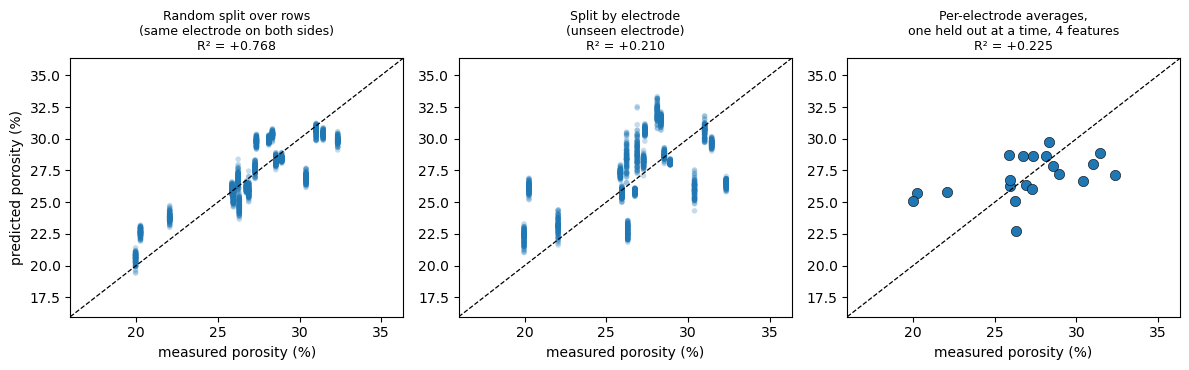

,model,features,R²,typical error (% porosity)
0,Predict the average,0,-0.108,3.407
1,Thickness only,1,-0.109,3.408
2,All engineered features,20,0.157,2.972
3,One summary per channel,4,0.225,2.849


random split over rows : R² = +0.768
split by electrode     : R² = +0.210


In [18]:
# loading the scikit learn libraries
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# split the data into trainig and testing sets.
y_rows = POROSITY[np.searchsorted(SAMPLE_IDS, sid)]
model = make_pipeline(StandardScaler(), Ridge(alpha=ALPHA))
pred_random = cross_val_predict(model, X_rows, y_rows, cv=KFold(5, shuffle=True, random_state=0))
pred_group  = cross_val_predict(model, X_rows, y_rows, cv=GroupKFold(5), groups=sid)
r2_random = r2_score(y_rows, pred_random)
r2_group = r2_score(y_rows, pred_group)

def loo_predict(X, y, alpha=ALPHA):
    # Hold out one electrode at a time. Scaling and coefficients are fitted on the
    # other 19 only, then used to predict the one held back.
    p = np.empty(len(y))
    for h in range(len(y)):
        tr = np.arange(len(y)) != h
        mu, sd = X[tr].mean(axis=0), X[tr].std(axis=0) + 1e-9
        p[h] = Ridge(alpha=alpha).fit((X[tr]-mu)/sd, y[tr]).predict(((X[h]-mu)/sd)[None])[0]
    return p

#down-selected feature modeling
SMALL = [NAMES.index(k) for k in ["peak_sum", "ir_mean", "i_crest", "power_factor"]]
p_all, p_small = loo_predict(X_s, y_s), loo_predict(X_s[:, SMALL], y_s)
p_mean = np.array([y_s[np.arange(N_SAMPLES) != h].mean() for h in range(N_SAMPLES)])
p_thick = loo_predict(X_s[:, [NAMES.index("thickness")]], y_s)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
lims = [POROSITY.min()-4, POROSITY.max()+4]
for ax, xv, yv, ttl, r2, sc in [
        (axes[0], y_rows, pred_random, "Random split over rows\n(same electrode on both sides)", r2_random, 16),
        (axes[1], y_rows, pred_group,  "Split by electrode\n(unseen electrode)", r2_group, 16),
        (axes[2], y_s, p_small, "Per-electrode averages,\none held out at a time, 4 features", r2_score(y_s, p_small), 55)]:
    ax.plot(lims, lims, "k--", lw=0.9)
    ax.scatter(xv, yv, s=sc, alpha=0.25 if sc < 20 else 1.0, edgecolor="none" if sc < 20 else "k", linewidth=0.4)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("measured porosity (%)")
    ax.set_title(f"{ttl}\nR² = {r2:+.3f}", fontsize=9)
axes[0].set_ylabel("predicted porosity (%)")
fig.tight_layout()
plt.show()

rmse = lambda a, b: float(np.sqrt(((a-b)**2).mean()))
res = pd.DataFrame([
    {"model": "Predict the average", "features": 0, "R²": r2_score(y_s, p_mean),
     "typical error (% porosity)": rmse(y_s, p_mean)},
    {"model": "Thickness only", "features": 1, "R²": r2_score(y_s, p_thick),
     "typical error (% porosity)": rmse(y_s, p_thick)},
    {"model": "All engineered features", "features": X_s.shape[1], "R²": r2_score(y_s, p_all),
     "typical error (% porosity)": rmse(y_s, p_all)},
    {"model": "One summary per channel", "features": len(SMALL), "R²": r2_score(y_s, p_small),
     "typical error (% porosity)": rmse(y_s, p_small)},
])
display(res.round(3))
print(f"random split over rows : R² = {r2_random:+.3f}")
print(f"split by electrode     : R² = {r2_group:+.3f}")

### Model Evaluation Results

The two train/test data split methods differ by R² = 0.60, even though they used the same modeling function. The random split scores well because the model is recognising electrodes it has already seen so it's not difficult for it to match a missing data point to it's corresponding electrode. But this random split method will fail if a new electrode is added to the testing dataset. For the split-by-electrode method, on an new electrode not used for training, the regression model only reduces the error from 3.4% to 2.8% of estimating porosity, approximatly a 16% improvement as compared to just directly estimating the average porosity. Given that measured porosity data only has a range of 12, I don't think this is that useful for estimation. 

Training on thickness feature can be ignored as it as a low R².

The 20-feature model scores below the 4-feature ("peak_sum", "ir_mean", "i_crest", "power_factor") only model, even though some more features correlated with porosity as shown in the previous analysis. With 19 training points, each additional coefficient costs more in model instability than a good estimation of porosity. Therefore, it is better to down select to 4-feature model for porosity estimation.

Those four feature quantities ("peak_sum", "ir_mean", "i_crest", "power_factor") were chosen after I had already seen how all 20 electrodes behaved in the correlation analysis above. This essentially means the 4-feature model R² score is an upper bound rather than a validated result.

So far, all this tells me is that the 20 electrode sample size might be not be enough.

---
### How confident should we be, and what would settle it?

Three checks: 
1. whether the score could have arisen by chance
2. how much it depends on choices I made
3. how many electrodes would be needed to answer the question properly.

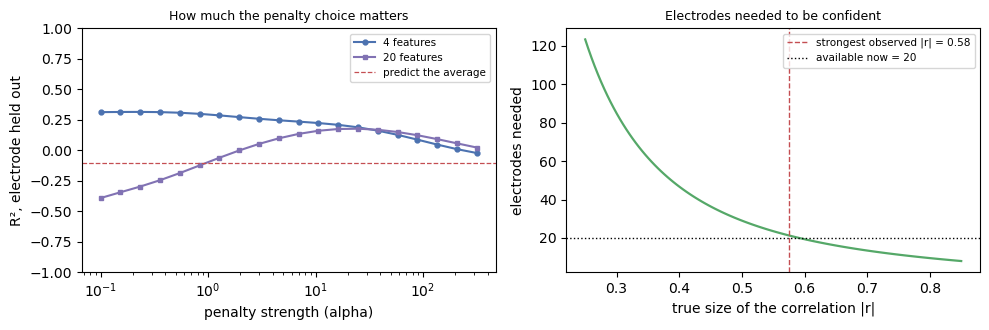

R² on the real data                     : +0.225
R² on shuffled porosity values          : -0.199
how often shuffling scored this well    : 0.012

R² across all penalty strengths tried   : -0.392 to +0.314

strongest correlation in the dataset    : |r| = 0.58
electrodes needed, one quantity tested  : 21
electrodes needed, 20 quantities screened : 38

95% confidence interval for a correlation of 0.58, at different study sizes:
   20 electrodes : +0.18 to +0.81   (width 0.63)
   40 electrodes : +0.32 to +0.75   (width 0.43)
   60 electrodes : +0.38 to +0.72   (width 0.35)
  100 electrodes : +0.43 to +0.69   (width 0.27)


In [19]:
# Check 1: could this score have come from nothing? Shuffle the porosity values
# among the 20 electrodes, so any real relationship is destroyed, then run the
# identical pipeline. If shuffled data scores this well too, the result is empty.
obs = r2_score(y_s, p_small)
shuffled = np.array([r2_score(yb, loo_predict(X_s[:, SMALL], yb))
                     for yb in (RNG.permutation(y_s) for _ in range(500))])
p_shuffle = (1 + (shuffled >= obs).sum()) / 501

# Check 2: how much does the answer depend on the penalty strength I picked?
alphas = np.logspace(-1, 2.5, 20)
sweep_small = [r2_score(y_s, loo_predict(X_s[:, SMALL], y_s, a)) for a in alphas]
sweep_all   = [r2_score(y_s, loo_predict(X_s, y_s, a)) for a in alphas]

# Check 3: how many electrodes would be needed to establish a correlation of a
# given size reliably? This is a standard calculation that depends only on the
# size of the correlation, not on any modelling choice I made above.
z_b = stats.norm.ppf(0.80)
r_grid = np.linspace(0.25, 0.85, 120)
r_best = float(np.abs([np.corrcoef(X_s[:, j], y_s)[0, 1] for j in range(X_s.shape[1])]).max())
n_at = lambda r, alpha=0.05: ((stats.norm.ppf(1-alpha/2) + z_b)/np.arctanh(r))**2 + 3

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].semilogx(alphas, sweep_small, "o-", ms=3.5, color="#4c72b0", label="4 features")
axes[0].semilogx(alphas, sweep_all, "s-", ms=3.5, color="#8172b3", label="20 features")
axes[0].axhline(r2_score(y_s, p_mean), color="#c44e52", ls="--", lw=0.9, label="predict the average")
axes[0].set_ylim(-1,1)
axes[0].set_xlabel("penalty strength (alpha)")
axes[0].set_ylabel("R², electrode held out")
axes[0].set_title("How much the penalty choice matters", fontsize=9)
axes[0].legend(fontsize=7.5)

axes[1].plot(r_grid, n_at(r_grid), color="#55a868", lw=1.6)
axes[1].axvline(r_best, color="#c44e52", ls="--", lw=1.0,
                label=f"strongest observed |r| = {r_best:.2f}")
axes[1].axhline(N_SAMPLES, color="k", ls=":", lw=1.0, label=f"available now = {N_SAMPLES}")
axes[1].set_xlabel("true size of the correlation |r|")
axes[1].set_ylabel("electrodes needed")
axes[1].set_title("Electrodes needed to be confident", fontsize=9)
axes[1].legend(fontsize=7.5)
fig.tight_layout()
plt.show()

print(f"R² on the real data                     : {obs:+.3f}")
print(f"R² on shuffled porosity values          : {np.median(shuffled):+.3f}")
print(f"how often shuffling scored this well    : {p_shuffle:.3f}")
print()
print(f"R² across all penalty strengths tried   : "
      f"{min(min(sweep_small), min(sweep_all)):+.3f} to "
      f"{max(max(sweep_small), max(sweep_all)):+.3f}")
print()
print(f"strongest correlation in the dataset    : |r| = {r_best:.2f}")
print(f"electrodes needed, one quantity tested  : {n_at(r_best):.0f}")
print(f"electrodes needed, {X_s.shape[1]} quantities screened : "
      f"{n_at(r_best, 0.05/X_s.shape[1]):.0f}")

# What would a bigger study actually buy, expressed in the same units as the
# finding rather than as an abstract sample size?
print(f"\n95% confidence interval for a correlation of {r_best:.2f}, at different study sizes:")
for n in [N_SAMPLES, 40, 60, 100]:
    lo, hi = confidence_interval(r_best, n)
    print(f"  {n:3d} electrodes : {lo:+.2f} to {hi:+.2f}   (width {hi-lo:.2f})")

### Model Check Interpretation

Shuffled porosity values score this well aboout 1% of the time. Hence, the relationship is unlikely to be chance.

Across penalty strengths and feature sets, R² ranges from $-0.39$ to $+0.31$. The R² spread caused by my own penalty choices is wider than the effect I am trying to measure. This reinforces to me that we need more electrode samples to create a porosity predictive model.

The check confirms that even the strongest correlation in the dataset would need around 21 electrodes, if I had specified one strongest feature with the highest correlation with porosity, or around 38 electrodes if I screen 20 candidate features. Validating a model rather than confirming one correlation needs more electrode samples, because a held-out electrode test set has to come out of the same data set. 

Furthermore, a correlation of 0.58 measured on 20 electrodes carries a confidence interval of 0.18 to 0.81. On 40 electrodes that narrows to 0.32 to 0.75, and on 60 to 0.38 to 0.72. So, having new data from more electrodes will not only give a better porosity prediction for an unknown electrode it will also make the prediction more reliable.

---
### Final Conclusions

**What this dataset supports**

1. Almost all variation comes from differences between electrodes rather than scatter within one, in all three channels, with no drift over the run. The correlations found are real differences between electrodes.
2. The plasma does respond to porosity through three physically independent channels. Emission at specific wavelengths rises for increase in porosity (r = +0.52, confidence interval +0.10 to +0.78) while the background stays flat; the discharge current becomes smoother and less spiky (r = −0.58, range −0.81 to −0.18, and with zero correlation with thickness). The thermal field shifts hotter (r = +0.41) but its interval, −0.04 to +0.72, includes zero, so that channel is suggestive rather than established.
3. The relationship are not by chance.

**What it does not support**

4. On an unseen electrode the error falls only about 16% below guessing the average, and the result is unstable across modeling choices, ranging from −0.39 to +0.31.
5. Every correlation carries a 95% confidence interval roughly 0.6 wide. Even the strongest is consistent with both a useful effect and a marginal one, which is the single clearest reason this data presently cannot be used to model for predictive porosity.
6. As stated in the assumption, I only tested for linear relationships. A non-linear or combined relationship could exist and would need further analysis.

**Recommendation to design/engineering team**

- The calculation above gives around 21 electrodes to confirm a single pre-specified correlation and around 38 electrodes while screening a feature set; a held-out test set comes out of the same budget. Sample count, not number of measurements, is the limiting constraint.
- Design the porosity spread rather than taking what the line produces. Deliberately including the extremes widens the range and is the cheapest way to make the study more informative.
- Hold out a test set of electrodes never touched during development.
- Capture the metadata and confirm the measurement units and calibration for all three channels.
- Decide the feature set before seeing the new labels. The modelling section shows that choosing quantities after the fact is where a reported number stops being trustworthy.

---
### AI-use disclosure

- **LLM used:** Anthropic's Claude.
- **Used for:** Debugging the correlation analysis, plotting, modeling and cross-validation code blocks, aiding with reconstructing the 1024 pixel structure of thermal images and brainstorming some electric waveform features to use.
- **Not used for:** Setting up the outline and preliminary analysis code of the feasability study including establishing the correlation analysis needed across the three data sets and model evaluation to perform to answer the assessment request. All assumptions, observations and conclusions from the analysis are the authors own interpretation of the data and results. All numerical results were produced by executing this notebook end to end. All data was treated as proprietary and was never uploaded to any commercial LLMs. 